In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation as animation
from scipy import special

import sys
sys.path.append('../')
from src.config import GROUP_PARAMS, calculate_velocity_grid, VELOCITY_SPACE, COLLISION_PARAMS

In [2]:
Ak_data = np.load('../simulation_data/Ak_t0_20250515_143757.npy')
bk_data = np.load('../simulation_data/bk_t0_20250515_143757.npy')
wxk_data = np.load('../simulation_data/wxk_t0_20250515_143757.npy')
wyk_data = np.load('../simulation_data/wyk_t0_20250515_143757.npy')
wzk_data = np.load('../simulation_data/wzk_t0_20250515_143757.npy')
meta_data = np.load('../simulation_data/metadata_t0_20250515_143757.npy', allow_pickle=True)

print(wzk_data)

[[[[5.71999122e-19]]

  [[8.57091552e-19]]]]


In [3]:
cx_vec, cy_vec, cz_vec, cx, cy, cz = calculate_velocity_grid()

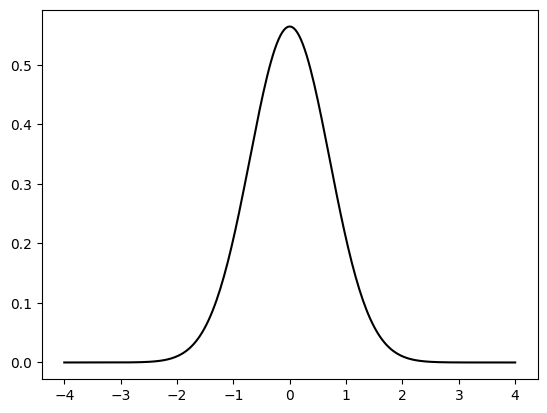

In [7]:
fig = plt.figure()
ax1 = fig.add_subplot(111)

combined_f = np.zeros((VELOCITY_SPACE['num_cx'], VELOCITY_SPACE['num_cy'], VELOCITY_SPACE['num_cz']))

for i in range(0, GROUP_PARAMS['num_groups_cx']):
    for j in range(0, GROUP_PARAMS['num_groups_cy']):
        for k in range(0, GROUP_PARAMS['num_groups_cz']):
            f = Ak_data[0, i, j, k] * np.exp(-bk_data[0, i, j, k] * ((cx - wxk_data[0, i, j, k])**2 + (cy - wyk_data[0, i, j, k])**2 + (cz - wzk_data[0, i, j, k])**2))

            lb_cx = GROUP_PARAMS['group_bounds_cx'][i, 0]
            ub_cx = GROUP_PARAMS['group_bounds_cx'][i, 1]
            lb_cy = GROUP_PARAMS['group_bounds_cy'][j, 0]
            ub_cy = GROUP_PARAMS['group_bounds_cy'][j, 1]
            lb_cz = GROUP_PARAMS['group_bounds_cz'][k, 0]
            ub_cz = GROUP_PARAMS['group_bounds_cz'][k, 1]

            fI = np.trapz(np.trapz(f[:, lb_cy:ub_cy, lb_cz:ub_cz], cz_vec[lb_cz:ub_cz], axis=2), cy_vec[lb_cy:ub_cy], axis=1)

            combined_f[lb_cx:ub_cx, lb_cy:ub_cy, lb_cz:ub_cz] = f[lb_cx:ub_cx, lb_cy:ub_cy, lb_cz:ub_cz]

combined_f_Ix = np.trapz(np.trapz(combined_f, cy_vec, axis=1), cx_vec, axis=0)
f0 = 1 / (np.pi**1.5) * np.exp(-1 * (cx**2 + cy**2 + cz**2))
f0I = np.trapz(np.trapz(f0, cz_vec, axis=2), cy_vec, axis=1)

ax1.plot(cx_vec, combined_f_Ix, color='black')
ax1.plot(cx_vec, f0I, color='red')

plt.show()

In [6]:
Ak = Ak_data[0, 0, 0, 0]
bk = bk_data[0, 0, 0, 0]
wxk = wxk_data[0, 0, 0, 0]
wyk = wyk_data[0, 0, 0, 0]
wzk = wzk_data[0, 0, 0, 0]

I0x = np.sqrt(np.pi / (4 * bk)) * (special.erf(np.sqrt(bk) * (GROUP_PARAMS['cf_cx'][0] - wxk)) - special.erf(np.sqrt(bk) * (GROUP_PARAMS['ci_cx'][0] - wxk)))
I0y = np.sqrt(np.pi / (4 * bk)) * (special.erf(np.sqrt(bk) * (GROUP_PARAMS['cf_cy'][0] - wyk)) - special.erf(np.sqrt(bk) * (GROUP_PARAMS['ci_cy'][0] - wyk)))
I0z = np.sqrt(np.pi / (4 * bk)) * (special.erf(np.sqrt(bk) * (GROUP_PARAMS['cf_cz'][0] - wzk)) - special.erf(np.sqrt(bk) * (GROUP_PARAMS['ci_cz'][0] - wzk)))

I1x = (np.exp(-bk * (GROUP_PARAMS['ci_cx'][0] - wxk)**2) - np.exp(-bk * (GROUP_PARAMS['cf_cx'][0] - wxk)**2)) / (2 * bk)
I1y = (np.exp(-bk * (GROUP_PARAMS['ci_cy'][0] - wyk)**2) - np.exp(-bk * (GROUP_PARAMS['cf_cy'][0] - wyk)**2)) / (2 * bk)
I1z = (np.exp(-bk * (GROUP_PARAMS['ci_cz'][0] - wzk)**2) - np.exp(-bk * (GROUP_PARAMS['cf_cz'][0] - wzk)**2)) / (2 * bk)

I2x = -np.sqrt(np.pi) / (2 * np.sqrt(bk)) * \
        ((np.exp(-bk * (GROUP_PARAMS['cf_cx'][0] - wxk)**2) * (GROUP_PARAMS['cf_cx'][0] - wxk))/np.sqrt(np.pi * bk) - (np.exp(-bk * (GROUP_PARAMS['ci_cx'][0] - wxk)**2) * (GROUP_PARAMS['ci_cx'][0] - wxk))/np.sqrt(np.pi * bk)) + \
            np.sqrt(np.pi)/(4 * np.sqrt(bk**3)) * (special.erf(np.sqrt(bk) * (GROUP_PARAMS['cf_cx'][0] - wxk)) - special.erf(np.sqrt(bk) * (GROUP_PARAMS['ci_cx'][0] - wxk)))
I2y = -np.sqrt(np.pi) / (2 * np.sqrt(bk)) * \
    ((np.exp(-bk * (GROUP_PARAMS['cf_cy'][0] - wyk)**2) * (GROUP_PARAMS['cf_cy'][0] - wyk))/np.sqrt(np.pi * bk) - (np.exp(-bk * (GROUP_PARAMS['ci_cy'][0] - wyk)**2) * (GROUP_PARAMS['ci_cy'][0] - wyk))/np.sqrt(np.pi * bk)) + \
        np.sqrt(np.pi)/(4 * np.sqrt(bk**3)) * (special.erf(np.sqrt(bk) * (GROUP_PARAMS['cf_cy'][0] - wyk)) - special.erf(np.sqrt(bk) * (GROUP_PARAMS['ci_cy'][0] - wyk)))
I2z = -np.sqrt(np.pi) / (2 * np.sqrt(bk)) * \
    ((np.exp(-bk * (GROUP_PARAMS['cf_cz'][0] - wzk)**2) * (GROUP_PARAMS['cf_cz'][0] - wzk))/np.sqrt(np.pi * bk) - (np.exp(-bk * (GROUP_PARAMS['ci_cz'][0] - wzk)**2) * (GROUP_PARAMS['ci_cz'][0] - wzk))/np.sqrt(np.pi * bk)) + \
        np.sqrt(np.pi)/(4 * np.sqrt(bk**3)) * (special.erf(np.sqrt(bk) * (GROUP_PARAMS['cf_cz'][0] - wzk)) - special.erf(np.sqrt(bk) * (GROUP_PARAMS['ci_cz'][0] - wzk)))

print('density:', Ak * I0x * I0y * I0z)
print('ux:', Ak * (I1x + wxk * I0x) * I0y * I0z)
print('uy:', Ak * I0x * (I1y + wyk * I0y) * I0z)
print('uz:', Ak * I0x * I0y * (I1z + wzk * I0z))
print('energy:', (Ak * (I2x + wxk**2 * I0x + 2 * wxk * I1x) * I0y * I0z) + (Ak * (I2y + 2 * wyk * I1y + wyk**2 * I0y) * I0x * I0z) + (Ak * (I2z + 2 * wzk * I1z + wzk**2 * I0z) * I0x * I0y))

density: 0.49999997673317337
ux: -0.28204250551437443
uy: -5.702795011370692e-18
uz: 2.8599954784206365e-19
energy: 0.749999582108783


In [49]:
x = [1.0, -0.2, -0.2, -0.2]
ci_cx = -3.0
cf_cx = 0.0
ci_cy = -3.0
cf_cy = 0.0
ci_cz = -3.0
cf_cz = 0.0
A = 0.18

I0x = np.sqrt(np.pi / (4 * x[0])) * (special.erf(np.sqrt(x[0]) * (cf_cx - x[1])) - special.erf(np.sqrt(x[0]) * (ci_cx - x[1])))
I0y = np.sqrt(np.pi / (4 * x[0])) * (special.erf(np.sqrt(x[0]) * (cf_cy - x[2])) - special.erf(np.sqrt(x[0]) * (ci_cy - x[2])))
I0z = np.sqrt(np.pi / (4 * x[0])) * (special.erf(np.sqrt(x[0]) * (cf_cz - x[3])) - special.erf(np.sqrt(x[0]) * (ci_cz - x[3])))

I1x = (np.exp(-x[0] * (ci_cx - x[1])**2) - np.exp(-x[0] * (cf_cx - x[1])**2)) / (2 * x[0])
I1y = (np.exp(-x[0] * (ci_cy - x[2])**2) - np.exp(-x[0] * (cf_cy - x[2])**2)) / (2 * x[0])
I1z = (np.exp(-x[0] * (ci_cz - x[3])**2) - np.exp(-x[0] * (cf_cz - x[3])**2)) / (2 * x[0])

I2x = -np.sqrt(np.pi) / (2 * np.sqrt(x[0])) * \
    ((np.exp(-x[0] * (cf_cx - x[1])**2) * (cf_cx - x[1]))/np.sqrt(np.pi * x[0]) - (np.exp(-x[0] * (ci_cx - x[1])**2) * (ci_cx - x[1])) / np.sqrt(np.pi * x[0])) + \
        np.sqrt(np.pi)/(4 * np.sqrt(x[0]**3)) * (special.erf(np.sqrt(x[0]) * (cf_cx - x[1])) - special.erf(np.sqrt(x[0]) * (ci_cx - x[1])))
I2y = -np.sqrt(np.pi) / (2 * np.sqrt(x[0])) * \
    ((np.exp(-x[0] * (cf_cy - x[2])**2) * (cf_cy - x[2]))/np.sqrt(np.pi * x[0]) - (np.exp(-x[0] * (ci_cy - x[2])**2) * (ci_cy - x[2])) / np.sqrt(np.pi * x[0])) + \
        np.sqrt(np.pi)/(4 * np.sqrt(x[0]**3)) * (special.erf(np.sqrt(x[0]) * (cf_cy - x[2])) - special.erf(np.sqrt(x[0]) * (ci_cy - x[2])))
I2z = -np.sqrt(np.pi) / (2 * np.sqrt(x[0])) * \
    ((np.exp(-x[0] * (cf_cz - x[3])**2) * (cf_cz - x[3]))/np.sqrt(np.pi * x[0]) - (np.exp(-x[0] * (ci_cz - x[3])**2) * (ci_cz - x[3])) / np.sqrt(np.pi * x[0])) + \
        np.sqrt(np.pi)/(4 * np.sqrt(x[0]**3)) * (special.erf(np.sqrt(x[0]) * (cf_cz - x[3])) - special.erf(np.sqrt(x[0]) * (ci_cz - x[3])))

print(A * I0x * I0y * I0z)
print(A * (I1x + x[1] * I0x) * I0y * I0z)
print(A * (I2x + 2 * x[1] * I1x + x[1]**2 * I0x) * I0y * I0z + A * (I2y + 2 * x[2] * I1y + x[2]**2 * I0y) * I0x * I0z + A * (I2z + 2 * x[3] * I1z + x[3]**2 * I0z) * I0x * I0y)
print(A * (I2x + 2 * x[1] * I1x + x[1]**2 * I0x) * I0y * I0z)
print(A * (I2y + 2 * x[2] * I1y + x[2]**2 * I0y) * I0x * I0z)
print(A * (I2z + 2 * x[3] * I1z + x[3]**2 * I0z) * I0x * I0y)
print()

0.22897595973680587
-0.14727298260445545
0.43145336477389884
0.1438177882579663
0.1438177882579663
0.1438177882579663

